<img src="../images/cads-logo.png" style="height: 100px;" align=left> 
<img src="../images/sklearn-logo.png" style="height: 100px;" align=right>

# Supervised Machine Learning

# Table of Contents

- [Thinking about Model Validation](#Thinking-about-Model-Validation)
- [Cross Validation](#Cross-Validation)
- [Model validation the wrong way](#Model-validation-the-wrong-way)
    - [Question: Can you guess the result of the following cell?](#Question:-Can-you-guess-the-result-of-the-following-cell?)
- [Model validation the right way: Holdout sets](#Model-validation-the-right-way:-Holdout-sets)
- [Model validation via cross-validation](#Model-validation-via-cross-validation)
- [Grid Search](#Grid-Search)

# Thinking about Model Validation

In principle, model validation is very simple: after choosing a model and its hyperparameters, we can estimate how effective it is by applying it to some of the training data and comparing the prediction to the known value.

The following sections first show a naive approach to model validation and why it
fails, before exploring the use of holdout sets and cross-validation for more robust
model evaluation.

# Cross Validation

## Model validation the wrong way

Let's demonstrate the naive approach to validation using the Iris data, which we saw in the previous section. We will start by loading the data:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns; sns.set()

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Shape of X: (150, 4)
Shape of y: (150,)


Next we choose a model and hyperparameters. Here we'll use a *k*-neighbors classifier with ``n_neighbors=1``.
This is a very simple and intuitive model that says "the label of an unknown point is the same as the label of its closest training point:"

<img src='../images/KNN.png'>

In [3]:
from sklearn.neighbors import KNeighborsClassifier
model= KNeighborsClassifier(n_neighbors=1)

Then we train the model, and use it to predict labels for data we already know:

In [4]:
model.fit(X, y)
y_model = model.predict(X)

Finally, we compute the fraction of correctly labeled points:

### Question: Can you guess the result of the following cell?

In [5]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_model)

1.0

We see an accuracy score of 1.0, which indicates that 100% of points were correctly labeled by our model!
But is this truly measuring the expected accuracy? Have we really come upon a model that we expect to be correct 100% of the time?

As you may have gathered, the answer is no.
In fact, this approach contains a fundamental flaw: *it trains and evaluates the model on the same data*.
Furthermore, the nearest neighbor model is an *instance-based* estimator that simply stores the training data, and predicts labels by comparing new data to these stored points: except in contrived cases, it will get 100% accuracy *every time!*

## Model validation the right way: Holdout sets

So what can be done?
A better sense of a model's performance can be found using what's known as a *holdout set*: that is, we hold back some subset of the data from the training of the model, and then use this holdout set to check the model performance.
This splitting can be done using the ``train_test_split`` utility in Scikit-Learn:

In [6]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [7]:
from sklearn.model_selection import train_test_split

# split the data with 50% in each set
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=0,train_size=0.5)

#fit the model
model.fit(X_train, y_train)

# fit and evaluate the model on the second set of data
y_model = model.predict(X_test)

accuracy_score(y_test, y_model)

0.9066666666666666

In [8]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(75, 4)
(75,)
(75, 4)
(75,)


We see here a more reasonable result: the nearest-neighbor classifier is about 90% accurate on this hold-out set.
The hold-out set is similar to unknown data, because the model has not "seen" it before.

## Model validation via cross-validation

One disadvantage of using a holdout set for model validation is that we have lost a portion of our data to the model training.
In the above case, half the dataset does not contribute to the training of the model!
This is not optimal, and can cause problems – especially if the initial set of training data is small.

One way to address this is to use *cross-validation*; that is, to do a sequence of fits where each subset of the data is used both as a training set and as a validation set. Visually, it might look something like this:
<img src= "../images/2-fold-CV.png" style="height: 500px;">


Here we do two validation trials, alternately using each half of the data as a holdout set.
Using the split data from before, we could implement it like this:

**Question:**
Write the code that implements the accuracy described on the previous image

In [9]:
# solution
y1_model = model.fit(X_train, y_train).predict(X_test)
y2_model = model.fit(X_test, y_test).predict(X_train)
accuracy_score(y_test, y1_model), accuracy_score(y_train, y2_model)

(0.9066666666666666, 0.96)

What comes out are two accuracy scores, which we could combine (by, say, taking the mean) to get a better measure of the global model performance.
This particular form of cross-validation is a *two-fold cross-validation*—that is, one in which we have split the data into two sets and used each in turn as a validation set.

We could expand on this idea to use even more trials, and more folds in the data—for example, here is a visual depiction of five-fold cross-validation:

<img src='../images/CV.png'/>

Here we split the data into five groups, and use each of them in turn to evaluate the model fit on the other 4/5 of the data.
This would be rather tedious to do by hand, and so we can use Scikit-Learn's ``cross_val_score`` convenience routine to do it succinctly:

In [13]:
from sklearn.model_selection import cross_val_score

model= KNeighborsClassifier(n_neighbors=3)
scores = cross_val_score(model, X, y, cv=2)  
scores

array([0.96, 0.92])

In [14]:
print("Accuracy: {}".format(scores.mean()))

Accuracy: 0.94


By default, the score computed at each cv iteration is the `score` method of the estimator. It is possible to change this by using the scoring parameter. Take a look at all possible values for [scoring parameter](https://scikit-learn.org/stable/modules/model_evaluation.html).


In [15]:
scores_f1 = cross_val_score(model, X, y, cv=2, scoring='f1_macro')   
scores_f1, np.mean(scores_f1)

(array([0.95998399, 0.91987179]), np.float64(0.9399278942346169))

Repeating the validation across different subsets of the data gives us an even better idea of the performance of the algorithm.

Scikit-Learn implements a number of useful cross-validation schemes that are useful in particular situations; these are implemented via iterators in the ``cross_validation`` module.
For example, we might wish to go to the extreme case in which our number of folds is equal to the number of data points: that is, we train on all points but one in each trial.
This type of cross-validation is known as *leave-one-out* cross validation, and can be used as follows:

In [16]:
from sklearn.model_selection import LeaveOneOut

model= KNeighborsClassifier(n_neighbors=3)
scores = cross_val_score(model, X, y, cv=LeaveOneOut())
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Because we have 150 samples, the leave one out cross-validation yields scores for 150 trials, and the score indicates either successful (1.0) or unsuccessful (0.0) prediction.
Taking the mean of these gives an estimate of the error rate:

In [17]:
scores.mean()

np.float64(0.96)

Other cross-validation schemes can be used similarly.
For a description of what is available in Scikit-Learn, use IPython to explore the ``sklearn.cross_validation`` submodule, or take a look at Scikit-Learn's online [cross-validation documentation](http://scikit-learn.org/stable/modules/cross_validation.html).

**Exercise:**
Try to classify Iris data using KNN for n_neighbors=4. Use 5-fold cross validation and use Accuracy, Precision, Recall, F1-score as evaluation metrics.

In [19]:
from sklearn.model_selection import cross_val_score

knn4 = KNeighborsClassifier(n_neighbors=4)

metrics = {
    'Accuracy' : 'accuracy',
    'Precision': 'precision_macro',
    'Recall'   : 'recall_macro',
    'F1-score' : 'f1_macro',
}

for name, scorer in metrics.items():
    score = cross_val_score(knn4, X, y, cv=5, scoring=scorer)
    print(f"{name:10s}: mean={score.mean()}")

Accuracy  : mean=0.9733333333333334
Precision : mean=0.9757575757575758
Recall    : mean=0.9733333333333334
F1-score  : mean=0.9732664995822891


### Exercise
Try to classify 'indian_liver_patient.csv' data using KNN for n_neighbors=5 and Logistic Regression. Use 3-fold cross validation.

This data set contains 416 liver patient records and 167 non liver patient records collected from North East of Andhra Pradesh, India. The "Dataset" column is a class label used to divide groups into liver patient (liver disease) or not (no disease). 

In [20]:
liver = pd.read_csv("../Data/indian_liver_patient.csv")
liver.head(2)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,0


In [21]:
liver.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  583 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


In [22]:
#Assuming 0=no disease and 1=disease
liver.Dataset.value_counts()

Dataset
0    416
1    167
Name: count, dtype: int64

In [23]:
X = liver.drop('Dataset', axis=1)
y = liver.Dataset

In [24]:
X_dum=pd.get_dummies(X, drop_first=True)
X_dum

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Gender_Male
0,65,0.7,0.1,187,16,18,6.8,3.3,0.90,False
1,62,10.9,5.5,699,64,100,7.5,3.2,0.74,True
2,62,7.3,4.1,490,60,68,7.0,3.3,0.89,True
3,58,1.0,0.4,182,14,20,6.8,3.4,1.00,True
4,72,3.9,2.0,195,27,59,7.3,2.4,0.40,True
...,...,...,...,...,...,...,...,...,...,...
578,60,0.5,0.1,500,20,34,5.9,1.6,0.37,True
579,40,0.6,0.1,98,35,31,6.0,3.2,1.10,True
580,52,0.8,0.2,245,48,49,6.4,3.2,1.00,True
581,31,1.3,0.5,184,29,32,6.8,3.4,1.00,True


In [30]:
### KNN

from sklearn.preprocessing import MinMaxScaler
x_scaled = MinMaxScaler().fit_transform(X_dum)


knn_5= KNeighborsClassifier(n_neighbors=5)

metrics = {
    'Accuracy' : 'accuracy',
    'Precision': 'precision_macro',
    'Recall'   : 'recall_macro',
    'F1-score' : 'f1_macro',
}

for name, scorer in metrics.items():

    A_scores=cross_val_score(knn_5, x_scaled, y, cv=3, scoring=scorer)
    A_mean=np.mean(A_scores)
    print(f'Mean of {name}: {A_mean}')

    # print(f"{name:10s}: mean={score.mean()}")



Mean of Accuracy: 0.6552383469909243
Mean of Precision: 0.5797898665311592
Mean of Recall: 0.5726600255650928
Mean of F1-score: 0.5674280761189947


In [31]:
### Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_5= LogisticRegression()

metrics = {
    'Accuracy' : 'accuracy',
    'Precision': 'precision_macro',
    'Recall'   : 'recall_macro',
    'F1-score' : 'f1_macro',
}

for name, scorer in metrics.items():

    A_scores=cross_val_score(lr_5, x_scaled, y, cv=3, scoring=scorer)
    A_mean=np.mean(A_scores)
    print(f'Mean of {name}: {A_mean}')

    # print(f"{name:10s}: mean={score.mean()}")

Mean of Accuracy: 0.7169794695567892
Mean of Precision: 0.7758208345692875
Mean of Recall: 0.5114461677411317
Mean of F1-score: 0.4448353447534399


# Grid Search
Grid search is the process of performing hyper parameter tuning in order to determine the optimal values for a given model. Scikit-Learn provides automated tools to do this in the grid search module.

Here is an example of using grid search to find the optimal KNN model. This can be set up using Scikit-Learn's ``GridSearchCV`` meta-estimator:

Now let's load breast_cancer data that is available from sklearn datasets.

In [32]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = cancer.data
y= cancer.target
X.shape

(569, 30)

In [33]:
np.sum(y)

np.int64(357)

In [34]:
X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=42, train_size=.80,stratify=y)

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 20),
              'p': [1,2],
              'weights': ['uniform','distance']}

grid = GridSearchCV(KNeighborsClassifier(), 
                    param_grid, scoring='precision_macro',
                    cv=3)

In [ ]:
# What is the total number of models that grid search builds


Notice that like a normal estimator, this has not yet been applied to any data.
Calling the ``fit()`` method will fit the model at each grid point, keeping track of the scores along the way:

In [36]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2... 18, 19]), 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

Now that this is fit, we can ask for the best parameters as follows:

In [37]:
grid.best_params_

{'n_neighbors': np.int64(7), 'p': 1, 'weights': 'uniform'}

Finally, if we wish, we can use the best model and show the fit to our data using code from before:

In [39]:
model = grid.best_estimator_
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
print('classification_report:\n',classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

classification_report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



array([[38,  4],
       [ 2, 70]])

The grid search provides many more options, including the ability to specify a custom scoring function, to parallelize the computations, to do randomized searches, and more.

## Exercise:

Load the cancer dataset and choose the best classification algorithm with the best hyperparameters.

- Define X and y

- To simplify, remove missing values

- Split data to train and test

- Use 5 fold cross validation and grid search on train data

- Choose appropriate validation metric

- Set grid parameters for each classification algorithm

- Build the best models for each classification algorithm according to the best estimator (best hyperparameters) given by the grid search

- Compare the performance of the algorithms with the best hyperparametrs on the test data according to confusion matrix, recall, precision, F1, and auc metrics

In [44]:
df=pd.read_csv('../data/breast_cancer_wisconsin.csv')
df

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,0
695,841769,2,1,1,1,2,1.0,1,1,1,0
696,888820,5,10,10,3,7,3.0,8,10,2,1
697,897471,4,8,6,4,3,4.0,10,6,1,1


In [45]:
X = df.drop(['Id','Class'],axis=1)
y = df['Class']

In [55]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

In [46]:
# Replace '?' with NaN and drop rows with missing values
df_clean = df.replace('?', np.nan).dropna().copy()
df_clean['Bare.nuclei'] = df_clean['Bare.nuclei'].astype(int)
print(f"Rows after dropping missing values: {len(df_clean)}  (dropped {len(df) - len(df_clean)})")

Rows after dropping missing values: 683  (dropped 16)


In [47]:
X = df_clean.drop(['Id', 'Class'], axis=1)
y = df_clean['Class']
print("Class distribution:\n", y.value_counts())

Class distribution:
 Class
0    444
1    239
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train: {X_train.shape},  X_test: {X_test.shape}")

X_train: (546, 9),  X_test: (137, 9)


In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

best_models = {}  # store best estimators for final comparison

In [51]:
print("Train class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n",  y_test.value_counts())

Train class distribution:
 Class
0    355
1    191
Name: count, dtype: int64

Test class distribution:
 Class
0    89
1    48
Name: count, dtype: int64


In [52]:
X_train.dtypes

Cl.thickness       int64
Cell.size          int64
Cell.shape         int64
Marg.adhesion      int64
Epith.c.size       int64
Bare.nuclei        int64
Bl.cromatin        int64
Normal.nucleoli    int64
Mitoses            int64
dtype: object

**Knn**

In [53]:
param_grid_knn = {
    'n_neighbors': np.arange(1, 21),
    'weights'    : ['uniform', 'distance'],
    'p'          : [1, 2]
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1_macro')
grid_knn.fit(X_train_scaled, y_train)
print("Best params:", grid_knn.best_params_)
best_models['KNN'] = grid_knn.best_estimator_

Best params: {'n_neighbors': np.int64(12), 'p': 2, 'weights': 'distance'}


**Decision Tree**

In [56]:
param_grid_dt = {
    'max_depth'        : [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1_macro')
grid_dt.fit(X_train, y_train)
print("Best params:", grid_dt.best_params_)
best_models['Decision Tree'] = grid_dt.best_estimator_

Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}


**Logistic Regression**

In [57]:
param_grid_lr = {
    'C'       : [0.01, 0.1, 1, 10, 100],
    'solver'  : ['lbfgs', 'liblinear'],
    'max_iter': [500]
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='f1_macro')
grid_lr.fit(X_train_scaled, y_train)
print("Best params:", grid_lr.best_params_)
best_models['Logistic Regression'] = grid_lr.best_estimator_

Best params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}


**Support Vector Machine (SVM)**

In [58]:
param_grid_svm = {
    'C'     : [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svm, cv=5, scoring='f1_macro')
grid_svm.fit(X_train_scaled, y_train)
print("Best params:", grid_svm.best_params_)
best_models['SVM'] = grid_svm.best_estimator_

/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was depreca

Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was depreca

**PipeLine: Polynomial Logistic Regression**

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

pipe_lr = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('lr',   LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_pipe = {
    'poly__degree': [1, 2],
    'lr__C'       : [0.01, 0.1, 1, 10]
}

In [60]:
grid_pipe = GridSearchCV(pipe_lr, param_grid_pipe, cv=5, scoring='f1_macro')
grid_pipe.fit(X_train_scaled, y_train)
print("Best params:", grid_pipe.best_params_)
best_models['Pipeline LR'] = grid_pipe.best_estimator_

Best params: {'lr__C': 10, 'poly__degree': 2}


**Compare the best models on the test data**

In [61]:
y_pred  = best_models['KNN'].predict(X_test_scaled)
y_proba = best_models['KNN'].predict_proba(X_test_scaled)[:, 1]
print("=== KNN ===")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== KNN ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.92      0.96      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137

Confusion Matrix:
 [[85  4]
 [ 2 46]]
AUC: 0.9820


In [62]:
# Decision Tree was trained on unscaled data
y_pred  = best_models['Decision Tree'].predict(X_test)
y_proba = best_models['Decision Tree'].predict_proba(X_test)[:, 1]
print("=== Decision Tree ===")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.92      0.96      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137

Confusion Matrix:
 [[85  4]
 [ 2 46]]
AUC: 0.9558


In [63]:
y_pred  = best_models['Logistic Regression'].predict(X_test_scaled)
y_proba = best_models['Logistic Regression'].predict_proba(X_test_scaled)[:, 1]
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        89
           1       0.92      0.98      0.95        48

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.96      0.96      0.96       137

Confusion Matrix:
 [[85  4]
 [ 1 47]]
AUC: 0.9923


In [64]:
y_pred  = best_models['SVM'].predict(X_test_scaled)
y_proba = best_models['SVM'].predict_proba(X_test_scaled)[:, 1]
print("=== SVM ===")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== SVM ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.92      0.96      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137

Confusion Matrix:
 [[85  4]
 [ 2 46]]
AUC: 0.9925


In [65]:
y_pred  = best_models['Pipeline LR'].predict(X_test_scaled)
y_proba = best_models['Pipeline LR'].predict_proba(X_test_scaled)[:, 1]
print("=== Pipeline: Polynomial Logistic Regression ===")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== Pipeline: Polynomial Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        89
           1       0.92      0.98      0.95        48

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.96      0.96      0.96       137

Confusion Matrix:
 [[85  4]
 [ 1 47]]
AUC: 0.9909


In [66]:
results = []
for name, model in best_models.items():
    X_eval  = X_test if name == 'Decision Tree' else X_test_scaled
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    results.append({
        'Model'    : name,
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall'   : recall_score(y_test, y_pred, average='macro'),
        'F1'       : f1_score(y_test, y_pred, average='macro'),
        'AUC'      : roc_auc_score(y_test, y_proba)
    })

pd.DataFrame(results).set_index('Model').round(4)

,Precision,Recall,F1,AUC
Model,,,,
KNN,0.9485,0.9567,0.9523,0.9820
Decision Tree,0.9485,0.9567,0.9523,0.9558
Logistic Regression,0.9550,0.9671,0.9605,0.9923
SVM,0.9485,0.9567,0.9523,0.9925
Pipeline LR,0.9550,0.9671,0.9605,0.9909


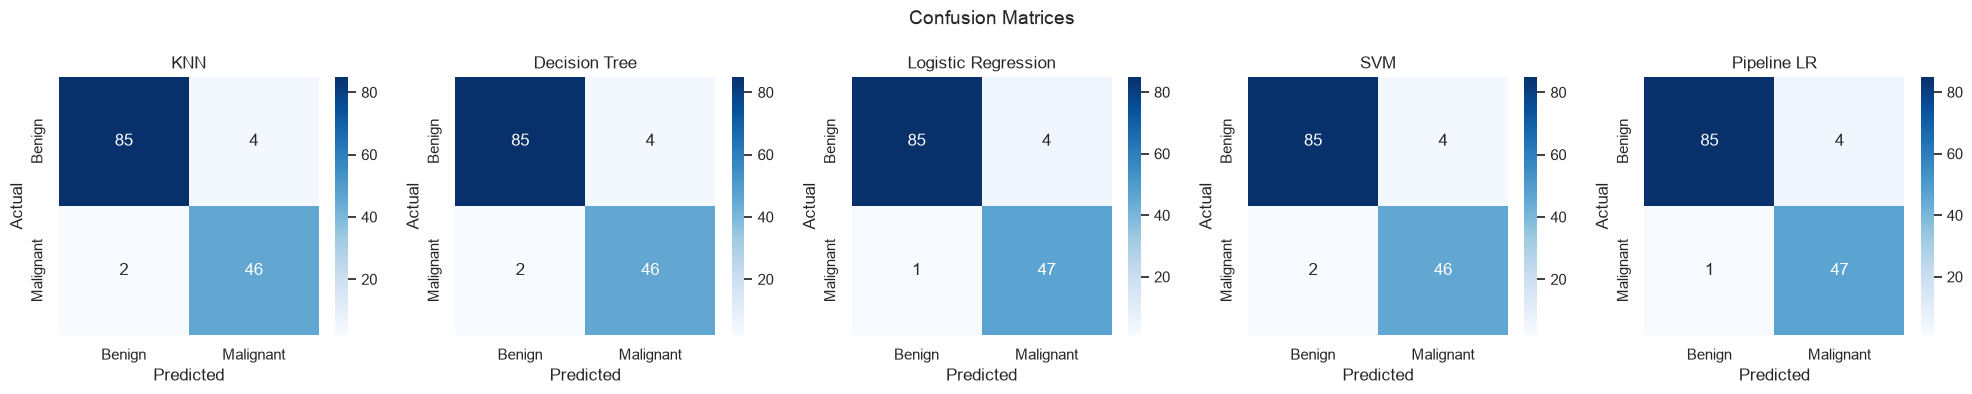

In [67]:
fig, axes = plt.subplots(1, len(best_models), figsize=(20, 4))
for ax, (name, model) in zip(axes, best_models.items()):
    X_eval = X_test if name == 'Decision Tree' else X_test_scaled
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

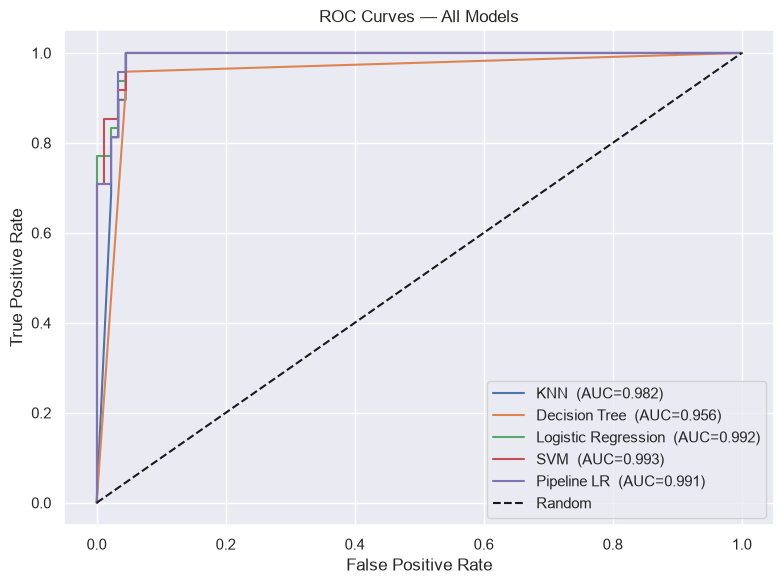

In [68]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, model in best_models.items():
    X_eval  = X_test if name == 'Decision Tree' else X_test_scaled
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=y_test.max())
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

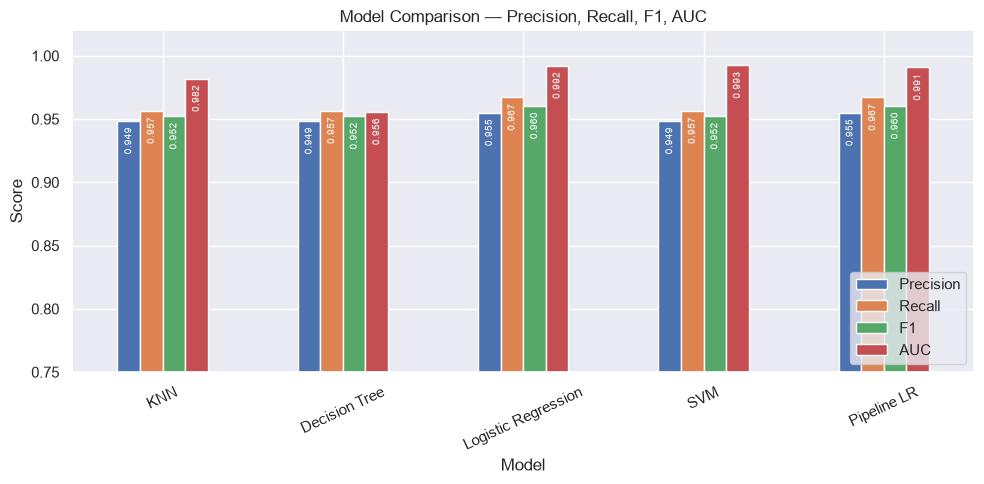

In [73]:
df_results = pd.DataFrame(results).set_index('Model')

ax = df_results.plot(kind='bar', figsize=(10, 5), ylim=(0.75, 1.02), rot=25)
for container in ax.containers:
    for bar in container:
        val = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 0.005,
            f'{val:.3f}',
            ha='center', va='top',
            fontsize=7, color='white',
            rotation=90
        )
plt.title('Model Comparison — Precision, Recall, F1, AUC')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()